# Nonlinear / Chaotic Graph Benchmarks vs Linear DMD

Most packaged KoopmanGraph tutorials train on **Laplacian diffusion plus forcing** —
dynamics that are already close to linear on the graph. That makes it hard to ask
the question this library is meant to answer:

> When node interactions are **genuinely nonlinear**, does a topology-aware
> GraphKoopman lift beat a classical vector DMD baseline under the same forecast
> protocol?

This notebook runs that comparison on four packaged nonlinear benchmarks:

1. **Kuramoto–Sivashinsky (KS)** — chaotic 1D PDE; used as a hard nonlinear example
   in EDMD with dictionary learning (Li et al., 2017, *Chaos*)
2. **Lorenz-96** — chaotic ODE on a periodic ring (Lorenz, 1996); coupling matches
   the graph used here
3. **Networked SIR** — nonlinear epidemic force-of-infection on a contact ring
4. **Cylinder-wake Hopf surrogate** — cached Stuart–Landau / POD teaching mesh
   (reduced-order wake motif; **not** Navier–Stokes DNS)

The goal is **not** a leaderboard claim. It is to demonstrate the new datasets,
show an apples-to-apples GraphKoopman vs DMD evaluation, and interpret when graph
structure helps.


## Methodology

Both models see the **same chronological split** of each sequence
(`temporal_split`: 70% train / 10% val / 20% test):

| Model | What it uses |
|-------|----------------|
| `GraphKoopmanModel` | GNN encoder/decoder + Schur-stable latent Koopman matrix `K` (topology via `edge_index`) |
| `DMDBaseline` | Flattened node features; linear map fit by least squares (**ignores** graph edges) |

Forecast quality uses the same **multi-origin RMSE** protocol as the METR-LA
tutorial: for each horizon $h$, average RMSE over every valid origin in the test
window and every lead time $1\ldots h$.

**Caveats (read before interpreting numbers):**

- Chaotic systems are seed- and horizon-sensitive; short training budgets (especially
  with short training budgets) can favor linear DMD.
- The cylinder-wake cache is a **nearly linear Hopf oscillator** on fixed modes — a
  teaching surrogate, not Navier–Stokes DNS — so vector DMD is expected to be strong.
- We report qualitative gaps, not a fixed “GraphKoopman must win by margin X” assert.


In [1]:
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import os
import random

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import torch

try:
    from IPython import get_ipython

    if get_ipython() is not None and not os.environ.get("PYTEST_CURRENT_TEST"):
        get_ipython().run_line_magic("matplotlib", "inline")
except (ImportError, NameError):
    pass

from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel
from koopman_graph.baselines import DMDBaseline
from koopman_graph.data import temporal_split
from koopman_graph.datasets import (
    CylinderWakeBenchmark,
    EpidemicNetworkBenchmark,
    KuramotoSivashinskyBenchmark,
    Lorenz96GraphBenchmark,
)

CI = bool(os.environ.get("PYTEST_CURRENT_TEST"))
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "font.size": 10,
    }
)


## Evaluation helpers

`multi_origin_rmse` mirrors notebook 03. `fit_compare` trains one GraphKoopman model
and one DMD baseline on the train split, then scores both on the held-out test
window. Results are stored for the summary plot below.


In [2]:
def multi_origin_rmse(predict_fn, test_seq, horizons: tuple[int, ...]) -> dict[int, float]:
    # RMSE averaged over all valid origins and lead times within each horizon.
    scores: dict[int, float] = {}
    for horizon in horizons:
        sq_errors: list[torch.Tensor] = []
        max_origin = test_seq.num_timesteps - horizon
        if max_origin <= 0:
            scores[horizon] = float("nan")
            continue
        for origin in range(0, max_origin):
            preds = predict_fn(test_seq[origin], horizon)
            for step in range(horizon):
                sq_errors.append((preds[step].x - test_seq[origin + 1 + step].x).pow(2))
        scores[horizon] = float(torch.stack(sq_errors).mean().sqrt())
    return scores


def fit_compare(
    name: str,
    sequence,
    *,
    in_channels: int,
    time_step: float,
    horizons: tuple[int, ...],
) -> dict[str, object]:
    # Train GraphKoopman + DMD and return structured multi-origin RMSE results.
    split = temporal_split(sequence, train_ratio=0.7, val_ratio=0.1, test_ratio=0.2)
    hidden = 16 if CI else 32
    latent = 12 if CI else 24
    epochs = 4 if CI else 40
    torch.manual_seed(SEED)
    model = GraphKoopmanModel(
        encoder=GNNEncoder(in_channels, hidden, latent, num_layers=2),
        decoder=GNNDecoder(latent, hidden, in_channels, num_layers=2),
        latent_dim=latent,
        time_step=time_step,
        koopman_parameterization="schur",
    )
    model.fit(split.train, epochs=epochs, lr=1e-3)
    dmd = DMDBaseline(time_step=time_step).fit(split.train)
    graph_rmses = multi_origin_rmse(
        lambda snapshot, horizon: model.predict(snapshot, steps=horizon),
        split.test,
        horizons,
    )
    dmd_rmses = multi_origin_rmse(
        lambda snapshot, horizon: dmd.predict(snapshot, steps=horizon),
        split.test,
        horizons,
    )
    print(f"\n{name}")
    print(f"{'horizon':>8} {'GraphKoopman':>14} {'DMD':>10}")
    for horizon in horizons:
        print(f"{horizon:>8} {graph_rmses[horizon]:>14.4f} {dmd_rmses[horizon]:>10.4f}")
    return {
        "name": name,
        "horizons": horizons,
        "graph": graph_rmses,
        "dmd": dmd_rmses,
        "split": split,
        "sequence": sequence,
    }


## Set up the four nonlinear systems

Generate (or load) each benchmark under a fixed seed. The quick-demo profile uses
smaller grids and shorter trajectories; the full path uses larger defaults.


In [3]:
ks = KuramotoSivashinskyBenchmark.generate(
    num_nodes=32 if CI else 64,
    num_timesteps=60 if CI else 300,
    burn_in=20 if CI else 80,
    domain_length=22.0,
    dt=0.25,
    topology="ring",
    seed=SEED,
)
l96 = Lorenz96GraphBenchmark.generate(
    num_nodes=12 if CI else 40,
    num_timesteps=80 if CI else 400,
    burn_in=20 if CI else 150,
    forcing=8.0,
    dt=0.05 if CI else 0.01,
    seed=SEED,
)
sir = EpidemicNetworkBenchmark.generate(
    num_nodes=16 if CI else 36,
    num_timesteps=30 if CI else 80,
    topology="ring",
    seed=SEED,
)
wake = CylinderWakeBenchmark.load_sequence()
if CI:
    wake = wake.slice(0, 40)

systems = {
    "Kuramoto–Sivashinsky": ks,
    "Lorenz-96": l96,
    "Networked SIR": sir,
    "Cylinder-wake surrogate": wake,
}
for name, seq in systems.items():
    print(
        f"{name:24s}  T={seq.num_timesteps:4d}  N={seq.num_nodes:3d}  "
        f"F={seq.in_channels}"
    )


Kuramoto–Sivashinsky      T= 300  N= 64  F=1
Lorenz-96                 T= 400  N= 40  F=1
Networked SIR             T=  80  N= 36  F=3
Cylinder-wake surrogate   T= 120  N= 72  F=1


### Snapshot of the dynamics

A quick look at each field before training: KS and Lorenz-96 should look irregular;
SIR shows a **spatial** infected front traveling around the ring (plus the usual
mean S/I/R epidemic curve is omitted here so the wave is visible); the wake
surrogate is a smooth, growing oscillation.


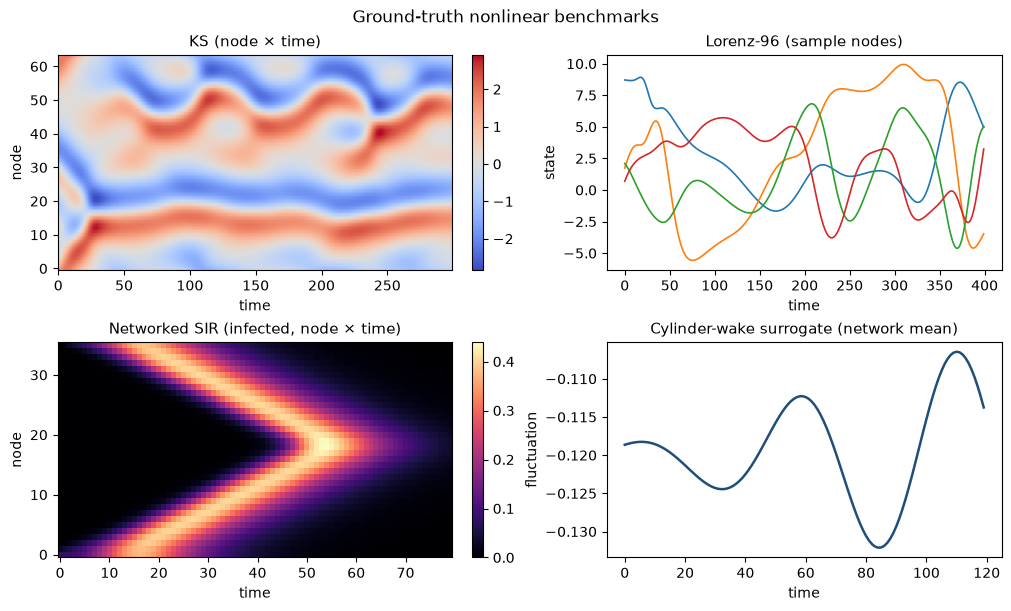

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6), constrained_layout=True)

# KS spacetime strip (node × time for channel 0)
ks_field = torch.stack([snap.x[:, 0] for snap in ks], dim=1).numpy()
im0 = axes[0, 0].imshow(ks_field, aspect="auto", cmap="coolwarm", origin="lower")
axes[0, 0].set_title("KS (node × time)")
axes[0, 0].set_xlabel("time")
axes[0, 0].set_ylabel("node")
fig.colorbar(im0, ax=axes[0, 0], fraction=0.046)

# Lorenz-96: a few node trajectories
for node in range(min(4, l96.num_nodes)):
    axes[0, 1].plot([float(l96[t].x[node, 0]) for t in range(l96.num_timesteps)], lw=1.2)
axes[0, 1].set_title("Lorenz-96 (sample nodes)")
axes[0, 1].set_xlabel("time")
axes[0, 1].set_ylabel("state")

# SIR: infected fraction over the ring (spatial traveling front)
sir_I = torch.stack([snap.x[:, 1] for snap in sir], dim=1).numpy()
im1 = axes[1, 0].imshow(sir_I, aspect="auto", cmap="magma", origin="lower", vmin=0.0)
axes[1, 0].set_title("Networked SIR (infected, node × time)")
axes[1, 0].set_xlabel("time")
axes[1, 0].set_ylabel("node")
fig.colorbar(im1, ax=axes[1, 0], fraction=0.046)

# Wake: network-mean fluctuation
wake_mean = [float(snap.x.mean()) for snap in wake]
axes[1, 1].plot(wake_mean, color="#1f4e79", lw=1.8)
axes[1, 1].set_title("Cylinder-wake surrogate (network mean)")
axes[1, 1].set_xlabel("time")
axes[1, 1].set_ylabel("fluctuation")

fig.suptitle("Ground-truth nonlinear benchmarks", fontsize=12)
plt.show()


## Train and evaluate

Fit GraphKoopman and DMD on each system with matched horizons. The quick-demo
profile uses a short epoch budget; the full path uses a modest research demo budget.


In [5]:
ks_horizons = (2, 4) if CI else (3, 6, 12)
l96_horizons = (2, 4) if CI else (5, 10, 20)
sir_horizons = (2, 4) if CI else (3, 6, 12)
wake_horizons = (2, 4) if CI else (3, 6, 12)

results = [
    fit_compare(
        "Kuramoto–Sivashinsky",
        ks,
        in_channels=1,
        time_step=0.25,
        horizons=ks_horizons,
    ),
    fit_compare(
        "Lorenz-96",
        l96,
        in_channels=1,
        time_step=0.05 if CI else 0.01,
        horizons=l96_horizons,
    ),
    fit_compare(
        "Networked SIR",
        sir,
        in_channels=3,
        time_step=1.0,
        horizons=sir_horizons,
    ),
    fit_compare(
        "Cylinder-wake surrogate",
        wake,
        in_channels=1,
        time_step=0.15,
        horizons=wake_horizons,
    ),
]



Kuramoto–Sivashinsky
 horizon   GraphKoopman        DMD
       3         0.5250     0.1761
       6         1.0216     0.3153
      12         1.9689     0.5949

Lorenz-96
 horizon   GraphKoopman        DMD
       5         4.4447    10.6597
      10         6.6101    17.5670
      20        10.5714    27.6060

Networked SIR
 horizon   GraphKoopman        DMD
       3         0.0705     0.0091
       6         0.1931     0.0163
      12         0.4614     0.0315

Cylinder-wake surrogate
 horizon   GraphKoopman        DMD
       3         0.1377     0.0053
       6         0.1816     0.0095
      12         0.3406     0.0181


## Display results

Print the mean multi-origin RMSE table, then plot **one panel per system with its
own y-axis**. Absolute RMSE scales differ by orders of magnitude (Lorenz-96 vs
SIR/wake), so a single shared-scale bar chart hides the smaller DMD bars.
Lower is better in every panel.


system                     GraphKoopman        DMD   Δ (GK−DMD)
----------------------------------------------------------------
Kuramoto–Sivashinsky             1.1718     0.3621       0.8097
Lorenz-96                        7.2087    18.6109     -11.4022
Networked SIR                    0.2417     0.0190       0.2227
Cylinder-wake surrogate          0.2200     0.0110       0.2090


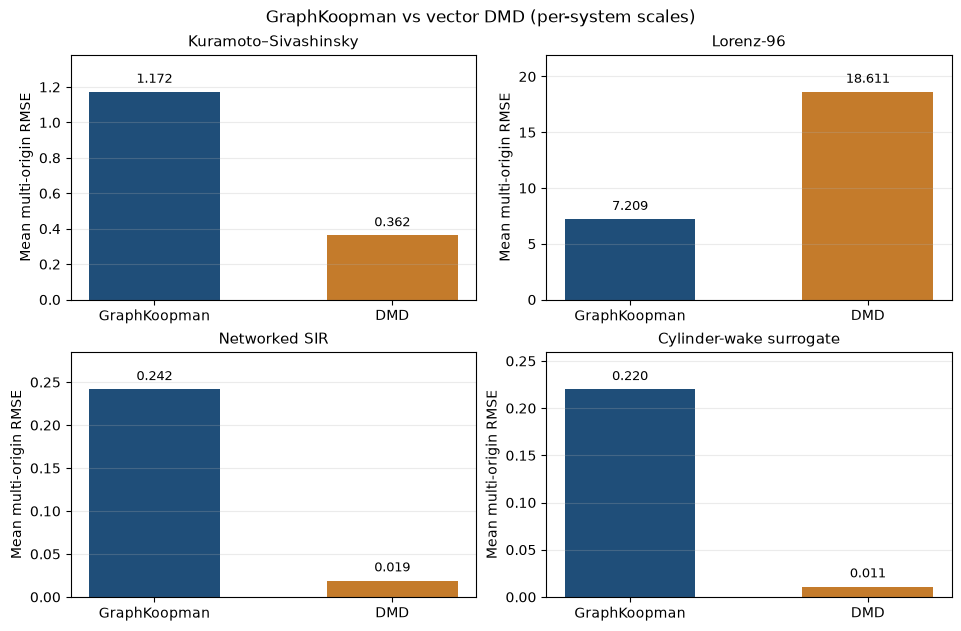

In [6]:
print(f"{'system':26s} {'GraphKoopman':>12} {'DMD':>10} {'Δ (GK−DMD)':>12}")
print("-" * 64)
summary_names: list[str] = []
summary_graph: list[float] = []
summary_dmd: list[float] = []
for item in results:
    horizons = item["horizons"]
    g_mean = sum(item["graph"][h] for h in horizons) / len(horizons)
    d_mean = sum(item["dmd"][h] for h in horizons) / len(horizons)
    summary_names.append(item["name"])
    summary_graph.append(g_mean)
    summary_dmd.append(d_mean)
    print(f"{item['name']:26s} {g_mean:12.4f} {d_mean:10.4f} {g_mean - d_mean:12.4f}")

fig, axes = plt.subplots(2, 2, figsize=(9.5, 6.2), constrained_layout=True)
width = 0.55
for ax, name, g_mean, d_mean in zip(
    axes.ravel(), summary_names, summary_graph, summary_dmd, strict=True
):
    bars = ax.bar(
        [0, 1],
        [g_mean, d_mean],
        width=width,
        color=["#1f4e79", "#c47b2b"],
        tick_label=["GraphKoopman", "DMD"],
    )
    ax.set_title(name)
    ax.set_ylabel("Mean multi-origin RMSE")
    ax.grid(axis="y", alpha=0.25)
    ymax = max(g_mean, d_mean)
    for bar, val in zip(bars, [g_mean, d_mean], strict=True):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + 0.03 * ymax,
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )
    ax.set_ylim(0.0, ymax * 1.18 if ymax > 0 else 1.0)

fig.suptitle(
    "GraphKoopman vs vector DMD (per-system scales)",
    fontsize=12,
)
plt.show()


## Interpret the results

Read the **table** (and the per-system panels) with the methodology caveats in mind:

- **Lorenz-96** is the cleanest case for a topology-aware lift: the ODE coupling
  *is* the ring graph, and linear DMD on the flattened state often struggles as
  the chaotic amplitude grows. A GraphKoopman advantage here supports the
  notebook’s motivating question.
- **Kuramoto–Sivashinsky** is a hard chaotic PDE. Li et al. (2017) showed that
  *fixed* EDMD dictionaries can fail to reconstruct KS unless the observables are
  rich enough (their fix was dictionary learning). Here we compare a short-budget
  GraphKoopman model to linear DMD — a different experiment — so a DMD win under
  this protocol does **not** contradict that literature; it mainly shows that a
  lightly trained nonlinear lift is not automatically better than DMD on KS.
- **Networked SIR** is nonlinear but low-dimensional: the infected field forms a
  smooth spatial front on the ring, and a global linear map can still fit that
  front well on short horizons, so DMD may win under this protocol.
- **Cylinder-wake surrogate** is intentionally almost linear (fixed spatial modes
  modulated by a Stuart–Landau / Hopf amplitude equation). DMD matching or beating
  GraphKoopman here is expected for this reduced-order surrogate and does **not**
  contradict the value of graph lifts on harder systems, nor claims from full
  CFD wake studies.

Taken together, the point of the exercise is capability and honesty: the library
now ships nonlinear graph benchmarks on which GraphKoopman vs DMD is *testable*,
and the outcome depends on the system — exactly what was missing when every
packaged dataset was Laplacian diffusion.


## Takeaways

- **Goal revisited:** we can now stress-test topology-aware Koopman models on
  packaged nonlinear / chaotic graph dynamics instead of only linear diffusion.
- **Protocol:** same chronological split and multi-origin RMSE for
  `GraphKoopmanModel` and `DMDBaseline`.
- **Datasets:** `KuramotoSivashinskyBenchmark`, `Lorenz96GraphBenchmark`,
  `EpidemicNetworkBenchmark`, and cached `CylinderWakeBenchmark` live in
  `koopman_graph.datasets`.
- **Interpretation:** GraphKoopman is most compelling when graph coupling and
  nonlinearity matter (e.g. Lorenz-96 here); nearly linear surrogates and short
  chaotic budgets can favor DMD — report both sides.
- **Next steps:** increase epochs / latent size in a fuller demo for research plots;
  try EDMD dictionaries; see notebook 06 for a visual SIR showcase on the ring.
